<a href="https://colab.research.google.com/github/vitaly42a-creator/ML_course/blob/main/ML_Practice_1_1_Manakov_Vitaly_934_2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Задание 1. Анализ выбросов Постройте ящики с усами (boxplots) для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида Iris virginica по признаку sepal width. Какой процент наблюдений выходит за границы усов?


 ПЕРВЫЕ 5 СТРОК ДАННЫХ:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
ИНФОРМАЦИЯ О ДАННЫХ:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal

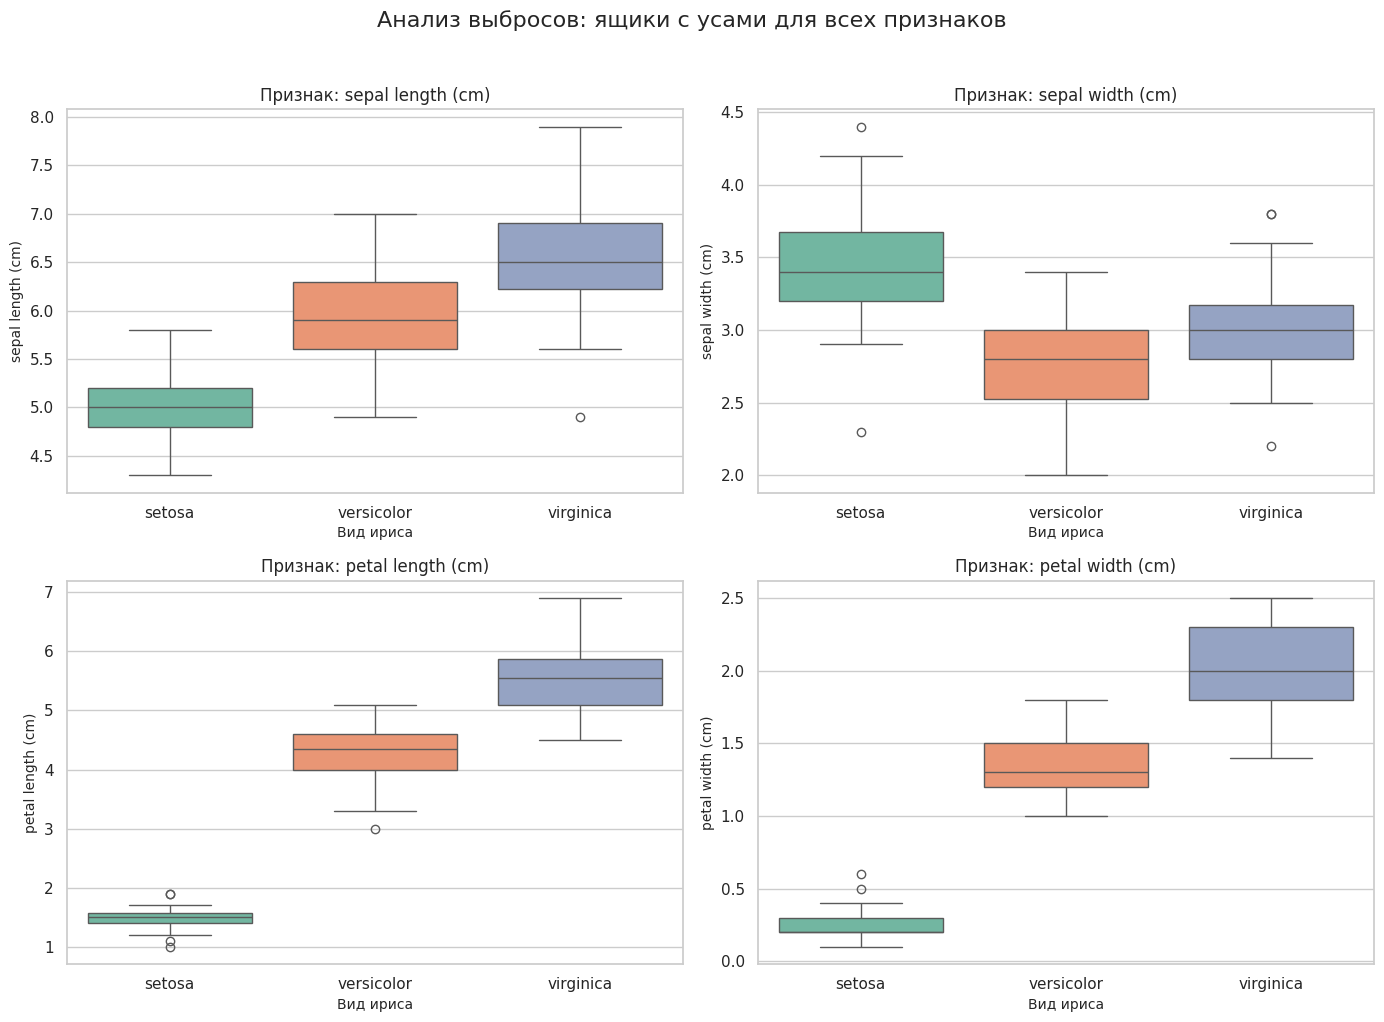

Анализ для Iris virginica по признаку sepal width

СТАТИСТИКА ДЛЯ Iris virginica (sepal width):
Всего наблюдений: 50
Минимальное значение: 2.200
Максимальное значение: 3.800
Q1 (25-й перцентиль): 2.800
Медиана (Q2): 3.000
Q3 (75-й перцентиль): 3.175
IQR (межквартильный размах): 0.375
Нижняя граница усов (Q1 - 1.5×IQR): 2.237
Верхняя граница усов (Q3 + 1.5×IQR): 3.738

РЕЗУЛЬТАТ АНАЛИЗА ВЫБРОСОВ:
Найдены выбросы, кол-во выбросов: 3
Процент наблюдений за границами усов: 6.00%
Значения-выбросы: [np.float64(2.2), np.float64(3.8), np.float64(3.8)]

ИТОГОВЫЙ ВЫВОД ПО ЗАДАНИЮ 1:
У вида Iris virginica по признаку 'sepal width' выбросы ЕСТЬ.
Процент наблюдений за границами усов: 6.00%
Значения-выбросы: [np.float64(2.2), np.float64(3.8), np.float64(3.8)]


In [2]:

!wget  -O '_end_seminar.xlsx' -q 'https://www.dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=0'
# Настройка среды и воспроизводимость
import numpy as np
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загрузка данных и преобразование в DataFrame
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
iris = load_iris()
# Преобразование в удобный формат с именами признаков
# Создаём DataFrame из числовых данных iris.data
# Названия столбцов берём из iris.feature_names
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Целевая переменная (числовые метки)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)  # Человекочитаемые названия

# Первичный анализ структуры
# Быстрый просмотр первых 5 строк
print("\n ПЕРВЫЕ 5 СТРОК ДАННЫХ:")
print(df.head())

# Информация о типах данных и пропусках
print("ИНФОРМАЦИЯ О ДАННЫХ:")
print(df.info())

# Статистика распределения: среднее, СКО, квартили
print("СТАТИСТИЧЕСКОЕ ОПИСАНИЕ:")
print(df.describe())

# Настройка стиля для графиков
sns.set(style="whitegrid", palette="Set2")

# ЗАДАНИЕ 1: Анализ выбросов с помощью boxplots

print("ЗАДАНИЕ 1: АНАЛИЗ ВЫБРОСОВ С ПОМОЩЬЮ ЯЩИКОВ С УСАМИ")

# Визуализация - ящики с усами для каждого признака с разбивкой по видам
# Создаём область из 4 графиков (2 строки × 2 столбца)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ выбросов: ящики с усами для всех признаков', fontsize=16, y=1.02)

for idx, col in enumerate(iris.feature_names):
    # Определяем позицию текущего графика в сетке 2x2
    ax = axes[idx // 2, idx % 2]
    boxplot = sns.boxplot(x='species', y=col, hue='species', data=df, ax=ax, palette='Set2', legend=False)
    ax.set_title(f'Признак: {col}', fontsize=12)
    ax.set_xlabel('Вид ириса', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
# Автоматически подгоняет расположение элементов графика
plt.tight_layout()
# Отображене графиков
plt.show()

print("Анализ для Iris virginica по признаку sepal width")

# Выделяем данные для вида Iris virginica
# Отбираем только строки, где species == 'virginica',
# и берём только столбец 'sepal width (cm)'
virginica_data = df[df['species'] == 'virginica']['sepal width (cm)']

# Рассчитываем статистики для определения выбросов
Q1 = virginica_data.quantile(0.25)
Q3 = virginica_data.quantile(0.75)
# Межквартильный размах:
# показывает ширину центральных 50% данных
IQR = Q3 - Q1

# Границы усов
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Находим выбросы
# Выбросами считаются значения,
# которые меньше нижней границы или больше верхней
outliers = virginica_data[(virginica_data < lower_whisker) | (virginica_data > upper_whisker)]
# Количество выбросов
outliers_count = len(outliers)
# Общее число наблюдений у вида virginica
total_count = len(virginica_data)
# Процент наблюдений, выходящих за границы усов
outliers_percentage = (outliers_count / total_count) * 100

print("\nСТАТИСТИКА ДЛЯ Iris virginica (sepal width):")
print(f"Всего наблюдений: {total_count}")
print(f"Минимальное значение: {virginica_data.min():.3f}")
print(f"Максимальное значение: {virginica_data.max():.3f}")
print(f"Q1 (25-й перцентиль): {Q1:.3f}")
print(f"Медиана (Q2): {virginica_data.median():.3f}")
print(f"Q3 (75-й перцентиль): {Q3:.3f}")
print(f"IQR (межквартильный размах): {IQR:.3f}")
print(f"Нижняя граница усов (Q1 - 1.5×IQR): {lower_whisker:.3f}")
print(f"Верхняя граница усов (Q3 + 1.5×IQR): {upper_whisker:.3f}")

# Результат анализа выбросов
print("\nРЕЗУЛЬТАТ АНАЛИЗА ВЫБРОСОВ:")
if outliers_count > 0:
    print(f"Найдены выбросы, кол-во выбросов: {outliers_count}")
    print(f"Процент наблюдений за границами усов: {outliers_percentage:.2f}%")
    print(f"Значения-выбросы: {sorted(outliers.values)}")

print("\nИТОГОВЫЙ ВЫВОД ПО ЗАДАНИЮ 1:")
if outliers_count > 0:
    print("У вида Iris virginica по признаку 'sepal width' выбросы ЕСТЬ.")
    print(f"Процент наблюдений за границами усов: {outliers_percentage:.2f}%")
    print(f"Значения-выбросы: {sorted(outliers.values)}")
else:
    print("У вида Iris virginica по признаку 'sepal width' выбросы ОТСУТСТВУЮТ.")
    print("Процент наблюдений, выходящих за границы усов: 0%")

Задание 2. Сравнение дисперсий Рассчитайте коэффициент вариации (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

In [3]:
# Список названий всех признаков датасета Iris
features = iris.feature_names
# Пустой словарь, в который будем сохранять коэффициент вариации для каждого признака
cv_results = {}

# Проходим по каждому признаку из списка features
for col in features:
    # Вычисляем среднее значение текущего признака
    mean_val = df[col].mean()
    # Вычисляем стандартное отклонение текущего признака
    # Оно показывает, насколько сильно значения разбросаны относительно среднего
    std_val = df[col].std()
    # Рассчитываем коэффициент вариации (CV)
    cv = (std_val / mean_val) * 100
    # Сохраняем результат в словарь:
    cv_results[col] = cv
    print(f"{col:20s} | mean = {mean_val:.3f} | std = {std_val:.3f} | CV = {cv:.2f}%")

# самый изменчивый признак
# Находим признак с максимальным коэффициентом вариации
most_variable = max(cv_results, key=cv_results.get)

print(f"Наиболее изменчивый признак: {most_variable}")
print(f"Максимальный коэффициент вариации: {cv_results[most_variable]:.2f}%")
print("Это важно, потому что признаки с высоким коэффициентом вариаци обычно сильнее нуждаются в масштабировании.")

sepal length (cm)    | mean = 5.843 | std = 0.828 | CV = 14.17%
sepal width (cm)     | mean = 3.057 | std = 0.436 | CV = 14.26%
petal length (cm)    | mean = 3.758 | std = 1.765 | CV = 46.97%
petal width (cm)     | mean = 1.199 | std = 0.762 | CV = 63.56%
Наиболее изменчивый признак: petal width (cm)
Максимальный коэффициент вариации: 63.56%
Это важно, потому что признаки с высоким коэффициентом вариаци обычно сильнее нуждаются в масштабировании.


Задание 3. Создание нового признака Создайте производный признак «соотношение длины и ширины лепестка» (petal_length / petal_width). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?


Первые строки с новым признаком:
   petal length (cm)  petal width (cm)  petal_ratio species
0                1.4               0.2          7.0  setosa
1                1.4               0.2          7.0  setosa
2                1.3               0.2          6.5  setosa
3                1.5               0.2          7.5  setosa
4                1.4               0.2          7.0  setosa


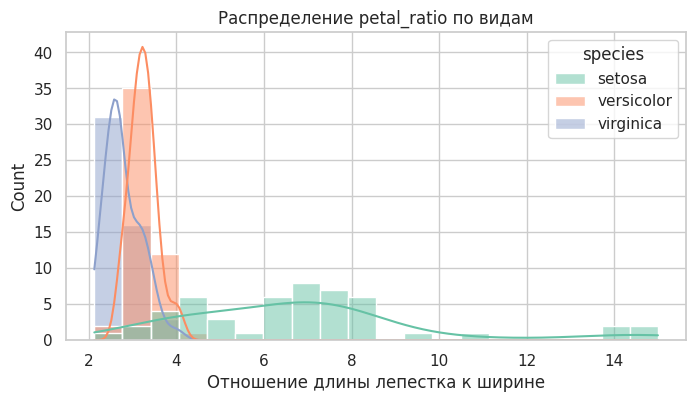

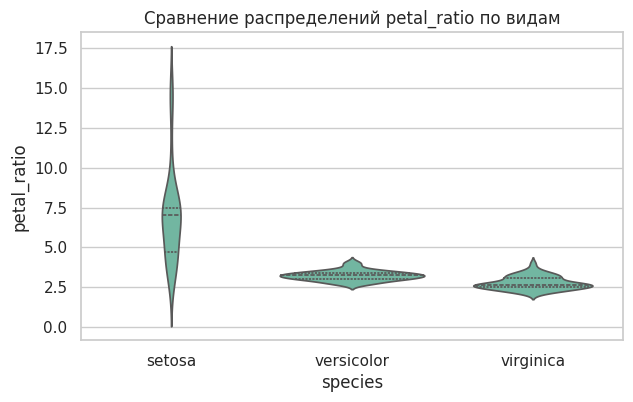

In [4]:
# Создаём новый столбец 'petal_ratio'
# Он равен отношению длины лепестка к ширине лепестка
df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']

print("\nПервые строки с новым признаком:")
print(df[['petal length (cm)', 'petal width (cm)', 'petal_ratio', 'species']].head())

# Гистограмма распределения по видам

# Создаём фигуру размером 8x4 дюйма
plt.figure(figsize=(8,4))
# Строим гистограмму нового признака petal_ratio
# data=df источник данных
# x='petal_ratio' по оси X откладываем новый признак
# hue='species' разными цветами показываем разные виды ирисов
# kde=True добавляем сглаженную кривую плотности распределения
# bins=20 делим диапазон значений на 20 интервалов
sns.histplot(data=df, x='petal_ratio', hue='species', kde=True, bins=20)
plt.title('Распределение petal_ratio по видам')
plt.xlabel('Отношение длины лепестка к ширине')
plt.show()

# Сравнение распределений (violinplot)

plt.figure(figsize=(7,4))
# Скрипичная диаграмма, распределения плотности данных
sns.violinplot(data=df, x='species', y='petal_ratio', inner='quartile')
plt.title('Сравнение распределений petal_ratio по видам')
plt.show()

Задание 1. Выявление мультиколлинеарности Найдите все пары признаков с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: Признак_1, Признак_2, Корреляция. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

Данные загружены. Форма: (178, 15)

Первые 3 строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1



 Типы данных и пропуски
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   alcohol                       178 non-null    float64 
 1   malic_acid                    178 non-null    float64 
 2   ash                           178 non-null    float64 
 3   alcalinity_of_ash             178 non-null    float64 
 4   magnesium                     178 non-null    float64 
 5   total_phenols                 178 non-null    float64 
 6   flavanoids                    178 non-null    float64 
 7   nonflavanoid_phenols          178 non-null    float64 
 8   proanthocyanins               178 non-null    float64 
 9   color_intensity               178 non-null    float64 
 10  hue                           178 non-null    float64 
 11  od280/od315_of_diluted_wines  178 non-null    float64 
 12  proline                  

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
count,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74
std,0.81,1.12,0.27,3.34,14.28
min,11.03,0.74,1.36,10.60,70.00
25%,12.36,1.60,2.21,17.20,88.00
50%,13.05,1.87,2.36,19.50,98.00
75%,13.68,3.08,2.56,21.50,107.00
max,14.83,5.80,3.23,30.00,162.00


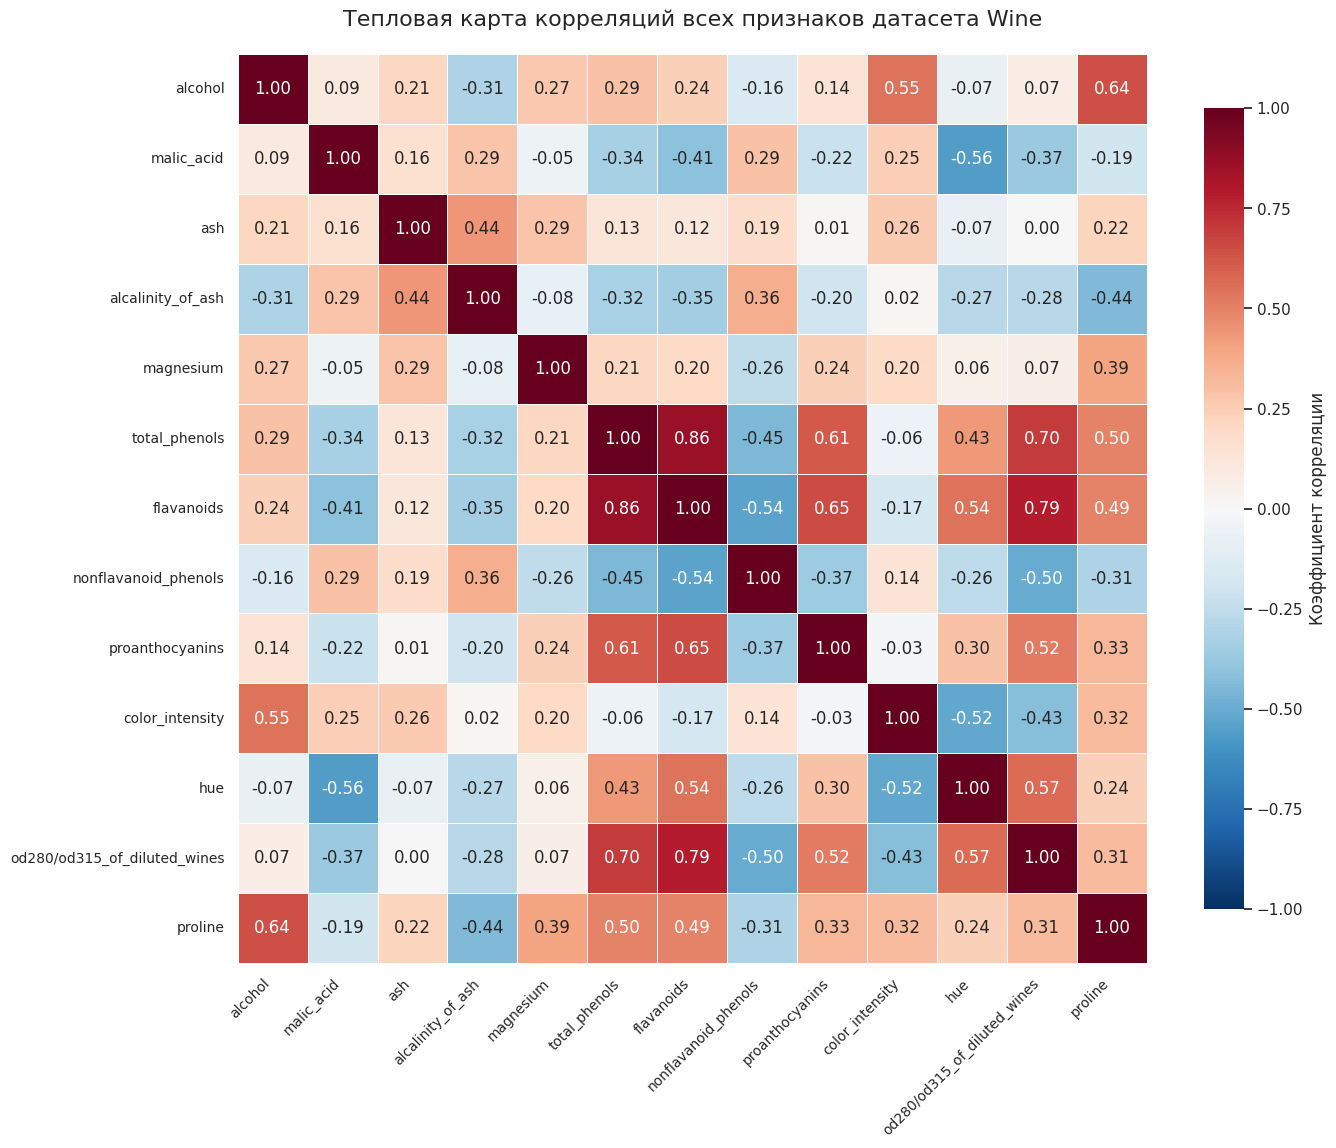


Количество пар с |r| > 0.7: 2

Признак, участвующий в наибольшем числе сильных корреляций: 'flavanoids'
Он встречается в 2 парах с |r| > 0.7

Пары с участием 'flavanoids':


,Признак_1,Признак_2,Корреляция
6,total_phenols,flavanoids,0.865
9,flavanoids,od280/od315_of_diluted_wines,0.787


In [5]:
import numpy as np
np.random.seed(42)  # Фиксируем случайность ДО всех операций

from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])

# df.shape показывает размер таблицы:
# (число строк, число столбцов)
print("Данные загружены. Форма:", df.shape)
print("\nПервые 3 строки:")
display(df.head(3))

print("\n Типы данных и пропуски")
print(df.info())

# Берём первые 5 столбцов и считаем описательные статистики:
# - среднее значение
# - стандартное отклонение
# - минимум / максимум
# - квартили
# round(2) округляет результат до 2 знаков после запятой
print("\n Описательная статистика (первые 5 признаков)")
display(df.iloc[:, :5].describe().round(2))

# Создаем тепловую карту для визуализации матрицы корреляций
plt.figure(figsize=(14, 12))
# Вычисляем матрицу корреляций только для числовых признаков
# df.iloc[:, :-2] — берём все столбцы, кроме последних двух (target и region)
# .corr() считает корреляцию между всеми парами признаков
corr_matrix = df.iloc[:, :-2].corr()  # Исключаем target и region
sns.heatmap(corr_matrix,
            annot=True,           # Отображаем значения корреляции
            fmt=".2f",            # Формат чисел (2 знака после запятой)
            cmap='RdBu_r',         # Цветовая схема (красный-белый-синий)
            vmin=-1, vmax=1,       # Диапазон значений корреляции
            center=0,              # Центр цветовой шкалы
            square=True,           # Квадратные ячейки
            linewidths=0.5,        # Линии между ячейками
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"})  # Настройки цветовой шкалы
plt.title('Тепловая карта корреляций всех признаков датасета Wine', fontsize=16, pad=20)
# Поворачиваем подписи по оси X на 45 градусов,
# чтобы длинные названия признаков не накладывались
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Оставляем только те элементы матрицы корреляций,
# для которых абсолютное значение корреляции больше 0.7
# corr_matrix.where(...) заменяет неподходящие значения на NaN
# .stack() сжимает матрицу в список пар без пустых значений
# .reset_index() превращает результат в обычную таблицу DataFrame
high_corr_pairs = (corr_matrix.where(np.abs(corr_matrix) > 0.7)
                   .stack()
                   .reset_index())

# Переименовываем столбцы для удобства чтения
high_corr_pairs.columns = ['Признак_1', 'Признак_2', 'Корреляция']

# Получаем список названий исходных признаков без target и region
feature_names = df.iloc[:, :-2].columns.tolist()
# Здесь мы оставляем только уникальные пары признаков.
# матрица корреляций симметрична, поэтому:
# A-B и B-A — это одна и та же пара
# Также на диагонали стоят корреляции признака с самим собой (=1)
# Условие:
# index(Признак_1) < index(Признак_2)
# позволяет оставить только одну сторону матрицы (верхний треугольник),
# тем самым убрать:
# - диагональные элементы
# - дублирующиеся пары
high_corr_pairs = high_corr_pairs[
    high_corr_pairs.apply(lambda row: feature_names.index(row['Признак_1']) < feature_names.index(row['Признак_2']), axis=1)
]

# Округляем корреляцию до 3 знаков
high_corr_pairs['Корреляция'] = high_corr_pairs['Корреляция'].round(3)

# Подсчет количества таких пар
num_pairs = len(high_corr_pairs)
print(f"\nКоличество пар с |r| > 0.7: {num_pairs}")

if num_pairs > 0:
    # Объединяем оба столбца с названиями признаков в один список
    all_features = pd.concat([high_corr_pairs['Признак_1'], high_corr_pairs['Признак_2']])
    # Считаем, сколько раз каждый признак встречается в сильных корреляциях
    feature_counts = all_features.value_counts()
    # Берём признак с максимальным числом вхождений
    most_correlated_feature = feature_counts.index[0]
    max_count = feature_counts.iloc[0]

    print(f"\nПризнак, участвующий в наибольшем числе сильных корреляций: '{most_correlated_feature}'")
    print(f"Он встречается в {max_count} парах с |r| > 0.7")

    # Детальный вывод для этого признака
    print(f"\nПары с участием '{most_correlated_feature}':")
    display(high_corr_pairs[
        (high_corr_pairs['Признак_1'] == most_correlated_feature) |
        (high_corr_pairs['Признак_2'] == most_correlated_feature)
    ])
else:
    print("\nПар с сильной корреляцией (|r| > 0.7) не обнаружено.")

Задание 2. Анализ асимметрии распределений Рассчитайте коэффициент асимметрии (skewness) для каждого признака с помощью scipy.stats.skew(). Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

Коэффициенты асимметрии признаков:


,Признак,Асимметрия
4,magnesium,1.089
1,malic_acid,1.031
9,color_intensity,0.861
12,proline,0.761
8,proanthocyanins,0.513
7,nonflavanoid_phenols,0.446
3,alcalinity_of_ash,0.211
5,total_phenols,0.086
6,flavanoids,0.025
10,hue,0.021



3 признака с наибольшей положительной асимметрией:


,Признак,Асимметрия
4,magnesium,1.089
1,malic_acid,1.031
9,color_intensity,0.861


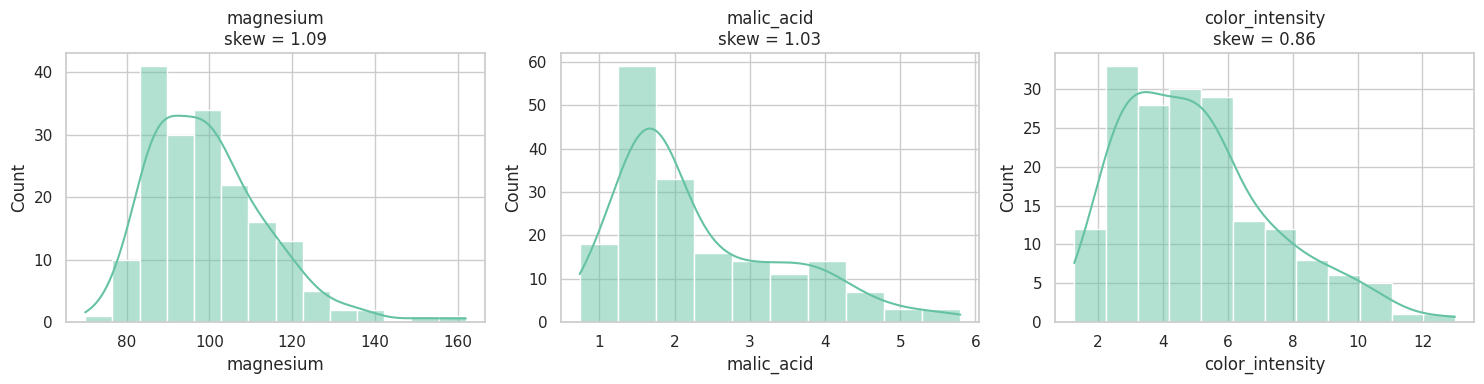

In [6]:
from scipy.stats import skew
# skew — функция для расчёта коэффициента асимметрии распределения
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Берём только числовые признаки (без целевых переменных)
# select_dtypes(include=[np.number]) оставляет только числовые столбцы
# drop(columns=['target'], errors='ignore') удаляет столбец target
# errors='ignore' нужен на случай, если столбца target нет тогда код не выдаст ошибку
num_df = df.select_dtypes(include=[np.number]).drop(columns=['target'], errors='ignore')

# Расчёт коэффициента асимметрии
# apply(...) применяет функцию к каждому столбцу DataFrame
# lambda x: skew(x.dropna()) означает:
# берём один столбец x
# удаляем пропуски через dropna()
# считаем коэффициент асимметрии с помощью skew()
skew_values = num_df.apply(lambda x: skew(x.dropna()))

# Таблица асимметрии
# Создаём новую таблицу из двух столбцов:
# 'Признак' названия признаков
# 'Асимметрия' рассчитанные значения skew
# skew_values.index названия столбцов
# skew_values.values сами числовые значения асимметрии
# sort_values(..., ascending=False) сортирует таблицу по убыванию,
# то есть сверху будут признаки с самой большой положительной асимметрией
skew_table = pd.DataFrame({
    'Признак': skew_values.index,
    'Асимметрия': skew_values.values
}).sort_values(by='Асимметрия', ascending=False)

print("Коэффициенты асимметрии признаков:")
display(skew_table.round(3))

# Топ-3 с наибольшей положительной асимметрией
top3_skew = skew_table[skew_table['Асимметрия'] > 0].head(3)

print("\n3 признака с наибольшей положительной асимметрией:")
display(top3_skew.round(3))

# Визуализация топ-3 признаков
plt.figure(figsize=(15, 4))

for i, feature in enumerate(top3_skew['Признак'], 1):
    # enumerate(..., 1) перебирает признаки и одновременно даёт номера:
    # 1, 2, 3
    # feature — название текущего признака
    plt.subplot(1, 3, i)
    # Создаём подграфик в сетке 1 строка × 3 столбца
    # i указывает, в какую позицию поместить текущий график
    sns.histplot(num_df[feature], kde=True)
    plt.title(f'{feature}\nskew = {skew_values[feature]:.2f}')

plt.tight_layout()
plt.show()

Задание 3. Создание «идеального» разделяющего признака Сконструируйте новый признак как линейную комбинацию двух существующих: wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity'] Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт коэффициента разделения классов (разница средних / сумма стандартных отклонений).

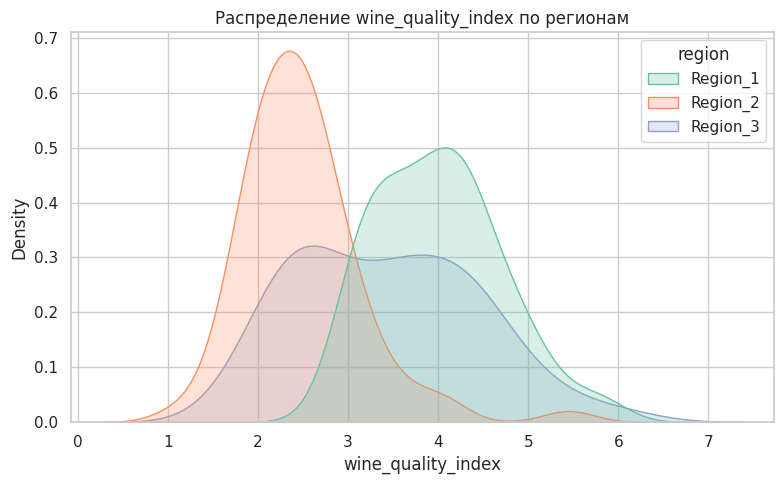

Разделение по flavanoids


,Класс_1,Класс_2,Признак,Separation
0,Region_1,Region_2,flavanoids,0.817
1,Region_1,Region_3,flavanoids,3.185
2,Region_2,Region_3,flavanoids,1.300


Разделение по color_intensity


,Класс_1,Класс_2,Признак,Separation
0,Region_1,Region_2,color_intensity,1.129
1,Region_1,Region_3,color_intensity,0.526
2,Region_2,Region_3,color_intensity,1.332


Разделение по wine_quality_index


,Класс_1,Класс_2,Признак,Separation
0,Region_1,Region_2,wine_quality_index,1.124
1,Region_1,Region_3,wine_quality_index,0.339
2,Region_2,Region_3,wine_quality_index,0.568



Средний коэффициент разделения:
flavanoids: 1.768
color_intensity: 0.996
wine_quality_index: 0.677
Вывод: новый признак wine_quality_index не даёт улучшения по сравнению с исходными признаками.


In [7]:
df['wine_quality_index'] = (
    0.6 * df['flavanoids'] +
    0.4 * df['color_intensity']
)

# Визуализация распределения по регионам

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Строим KDE-график (оценка плотности распределения) для нового признака
# data=df источник данных
# x='wine_quality_index' по оси X откладываем новый индекс качества
# hue='region' разными цветами показываем разные регионы / классы
# fill=True закрашиваем области под кривыми
# common_norm=False каждая группа нормируется отдельно,
sns.kdeplot(data=df, x='wine_quality_index', hue='region', fill=True, common_norm=False)
plt.title('Распределение wine_quality_index по регионам')
plt.tight_layout()
plt.show()

# Функция коэффициента разделения

def separation_score(data, feature, class_col='region'):
    # data таблица с данными
    # feature признак, для которого оцениваем разделение классов
    # class_col столбец с названиями классов (по умолчанию 'region')
    classes = data[class_col].unique()
    # Получаем список уникальных классов, например: Region_1, Region_2, Region_3
    results = []

    for i in range(len(classes)):
    # Внешний цикл перебирает первый класс
        for j in range(i + 1, len(classes)):
            # Внутренний цикл перебирает второй класс
            # j начинается с i+1, чтобы:
            # - не сравнивать класс с самим собой
            # - не дублировать пары (A-B и B-A)
            c1 = data[data[class_col] == classes[i]][feature]
            # Берём значения выбранного признака feature
            # только для первого класса
            c2 = data[data[class_col] == classes[j]][feature]
            # Берём значения того же признака
            # только для второго класса

            sep = abs(c1.mean() - c2.mean()) / (c1.std() + c2.std())
            # Рассчитываем коэффициент разделения классов:
            results.append({
                'Класс_1': classes[i],
                'Класс_2': classes[j],
                'Признак': feature,
                'Separation': sep
                # Сохраняем результат в список в виде словаря:
                # какая первая группа
                # какая вторая группа
                # какой признак анализировался
                # полученный коэффициент разделения
            })

    return pd.DataFrame(results)
    # Превращаем список результатов в таблицу DataFrame и возвращаем её из функции

# Сравнение разделяющей способности

sep_flav = separation_score(df, 'flavanoids')
# Считаем коэффициенты разделения для признака flavanoids
sep_color = separation_score(df, 'color_intensity')
# Считаем коэффициенты разделения для признака color_intensity
sep_index = separation_score(df, 'wine_quality_index')
# Считаем коэффициенты разделения для нового признака wine_quality_index

print("Разделение по flavanoids")
display(sep_flav.round(3))

print("Разделение по color_intensity")
display(sep_color.round(3))

print("Разделение по wine_quality_index")
display(sep_index.round(3))

# Для каждого признака считаем среднее значение Separation по всем парам классов
print("\nСредний коэффициент разделения:")
print(f"flavanoids: {sep_flav['Separation'].mean():.3f}")
print(f"color_intensity: {sep_color['Separation'].mean():.3f}")
print(f"wine_quality_index: {sep_index['Separation'].mean():.3f}")

if sep_index['Separation'].mean() > max(sep_flav['Separation'].mean(), sep_color['Separation'].mean()):
    # Если средний коэффициент разделения у нового признака выше,
    # чем у обоих исходных признаков, делаем вывод,
    # что новый признак действительно лучше разделяет классы
    print("Вывод: новый признак wine_quality_index улучшает разделение классов.")
else:
    print("Вывод: новый признак wine_quality_index не даёт улучшения по сравнению с исходными признаками.")
